# Entropic regularization and entropy barriers

This notebook generates `fig:sinkhorn-entropy-lp-geometry`.  The first row shows the penalized objective
$$
    p \mapsto \langle c,p\rangle + \varepsilon \sum_i p_i(\log p_i-1)
$$
on a triangular face of the transport polytope.  The second row repeats the same visual idea for a generic two-dimensional linear program with slack variables $s=b-Az$ and entropy $H(s)=\sum_i s_i(\log s_i-1)$.  The point is conceptual rather than algorithmic: entropy behaves like a smooth interior barrier, but OT is special because its entropy leads to diagonal Sinkhorn scalings.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon
from scipy.optimize import minimize

from figure_style import (
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
np.random.seed(0)

CMAP = LinearSegmentedColormap.from_list(
    "ot4ml_entropy", ["#fff7e6", "#fdd9a8", "#c99ac7", "#5b2c83"]
)


## Penalized objective on a triangular face

The barycentric coordinates $p=(p_1,p_2,p_3)$ represent three extreme couplings.  The minimizer is explicit:
$$
    p_i^\varepsilon = \frac{\exp(-c_i/\varepsilon)}{\sum_k \exp(-c_k/\varepsilon)}.
$$
A very large value of $\varepsilon$ places the minimizer close to the barycenter, while small $\varepsilon$ drives it toward the lowest-cost vertex.

In [2]:
fig_name = "sinkhorn-entropy-lp-geometry"
out = figure_dir(fig_name)

vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
cost = np.array([0.0, 0.58, 1.15])
reference = np.ones(3) / 3


def entropy_simplex(p):
    p = np.asarray(p)
    return np.sum(np.where(p > 0, p * np.log(p) - p, 0.0), axis=-1)


def bary_to_xy(p):
    return p @ vertices


def triangle_objective(p, epsilon):
    return p @ cost + epsilon * entropy_simplex(p)


def softmin_point(epsilon):
    weights = reference * np.exp(-cost / epsilon)
    return weights / weights.sum()


resolution = 115
bary = []
for i in range(resolution + 1):
    for j in range(resolution + 1 - i):
        bary.append(np.array([i, j, resolution - i - j], dtype=float) / resolution)
bary = np.asarray(bary)
points = bary_to_xy(bary)

eps_panels = [(12.0, "eps-large.pdf"), (0.45, "eps-medium.pdf"), (0.085, "eps-small.pdf")]
path_eps = np.geomspace(12.0, 0.035, 52)
path = np.vstack([softmin_point(eps) for eps in path_eps])
path_xy = bary_to_xy(path)


## A generic linear program with entropy on slacks

For a two-dimensional polyhedron $Az\leq b$, set $s(z)=b-Az$.  The displayed objective is
$$
    z \mapsto \ell^\top z + \varepsilon H(s(z)),
    \qquad
    H(s)=\sum_i s_i(\log s_i-1).
$$
This illustrates an entropy-on-slacks barrier.  It is visually useful, but the manuscript text explains why the canonical LP barrier is instead the Burg logarithmic barrier.

In [3]:
# Half-space representation of a compact hexagonal polyhedron.
A_poly = np.array([
    [-1.00, 0.00],
    [0.00, -1.00],
    [1.00, 0.00],
    [0.00, 1.00],
    [0.76, 0.86],
    [-0.86, 0.70],
])
b_poly = np.array([0.72, 0.60, 1.02, 0.84, 1.10, 0.92])
linear_poly = np.array([-0.64, 0.24])


def poly_vertices_from_halfspaces(A, b, tol=1e-9):
    vertices = []
    m = len(b)
    for i in range(m):
        for j in range(i + 1, m):
            M = np.vstack([A[i], A[j]])
            if abs(np.linalg.det(M)) < 1e-10:
                continue
            z = np.linalg.solve(M, np.array([b[i], b[j]]))
            if np.all(A @ z <= b + tol):
                vertices.append(z)
    vertices = np.unique(np.round(np.asarray(vertices), 12), axis=0)
    center = vertices.mean(axis=0)
    angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
    return vertices[np.argsort(angles)]


poly_vertices = poly_vertices_from_halfspaces(A_poly, b_poly)
poly_center = poly_vertices.mean(axis=0)


def entropy_slack(s):
    s = np.asarray(s)
    if np.any(s <= 0):
        return np.inf
    return float(np.sum(s * np.log(s) - s))


def poly_objective(z, epsilon):
    slack = b_poly - A_poly @ np.asarray(z)
    return float(linear_poly @ z + epsilon * entropy_slack(slack))


xg = np.linspace(poly_vertices[:, 0].min() - 0.03, poly_vertices[:, 0].max() + 0.03, 150)
yg = np.linspace(poly_vertices[:, 1].min() - 0.03, poly_vertices[:, 1].max() + 0.03, 150)
xx, yy = np.meshgrid(xg, yg)
grid_poly = np.c_[xx.ravel(), yy.ravel()]
inside = np.all(A_poly @ grid_poly.T <= b_poly[:, None] - 1e-6, axis=0)
poly_points = grid_poly[inside]


def solve_poly_minimizer(epsilon, start=None):
    values = np.array([poly_objective(z, epsilon) for z in poly_points])
    return poly_points[int(np.nanargmin(values))]


poly_eps_panels = [(2.8, "barrier-large.pdf"), (0.62, "barrier-medium.pdf"), (0.12, "barrier-small.pdf")]
poly_path_eps = np.geomspace(2.8, 0.050, 52)
poly_path = np.asarray([solve_poly_minimizer(eps) for eps in poly_path_eps])


## Exported panels

The PDFs contain no titles.  Temperature labels and the row interpretation are supplied in LaTeX.  Level sets are drawn over the colormap so the reader sees the actual penalized functional, not only the underlying linear objective.

In [4]:
def objective_levels(values, n=9):
    lo, hi = np.nanpercentile(values, [4, 96])
    if hi <= lo:
        hi = lo + 1.0
    return np.linspace(lo, hi, n)


def draw_triangle_panel(epsilon, filename, *, show_path=False):
    values = triangle_objective(bary, epsilon)
    p = softmin_point(epsilon)
    xy = bary_to_xy(p)
    fig, ax = plt.subplots(figsize=(2.02, 1.86))
    ax.tricontourf(points[:, 0], points[:, 1], values, levels=42, cmap=CMAP, zorder=1)
    ax.tricontour(points[:, 0], points[:, 1], values, levels=objective_levels(values), colors="#5b4a42", linewidths=0.34, alpha=0.42, zorder=2)
    ax.add_patch(Polygon(vertices, closed=True, facecolor="none", edgecolor=GRAY, linewidth=0.78, zorder=3))
    if show_path:
        colors = [interp_color(t, ORANGE, VIOLET) for t in np.linspace(0, 1, len(path_xy))]
        ax.plot(path_xy[:, 0], path_xy[:, 1], color=VIOLET, linewidth=1.08, alpha=0.82, zorder=5)
        ax.scatter(path_xy[:, 0], path_xy[:, 1], s=DIRAC_MARKER_SIZE * 0.55, marker="o", color=colors, edgecolor="none", zorder=6)
    else:
        ax.scatter([xy[0]], [xy[1]], s=DIRAC_MARKER_SIZE * 1.22, marker="o", color=VIOLET, edgecolor="none", zorder=6)
    ax.scatter(vertices[:, 0], vertices[:, 1], s=DIRAC_MARKER_SIZE * 0.70, marker="o", color=LIGHT_GRAY, edgecolor="none", zorder=4)
    ax.set_xlim(-0.075, 1.075)
    ax.set_ylim(-0.065, np.sqrt(3) / 2 + 0.075)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.035)
    plt.close(fig)


def draw_poly_panel(epsilon, filename, *, show_path=False):
    values = np.array([poly_objective(z, epsilon) for z in poly_points])
    zstar = solve_poly_minimizer(epsilon)
    fig, ax = plt.subplots(figsize=(2.02, 1.86))
    ax.tricontourf(poly_points[:, 0], poly_points[:, 1], values, levels=44, cmap=CMAP, zorder=1)
    ax.tricontour(poly_points[:, 0], poly_points[:, 1], values, levels=objective_levels(values), colors="#5b4a42", linewidths=0.34, alpha=0.42, zorder=2)
    ax.add_patch(Polygon(poly_vertices, closed=True, facecolor="none", edgecolor=GRAY, linewidth=0.78, zorder=3))
    if show_path:
        colors = [interp_color(t, ORANGE, VIOLET) for t in np.linspace(0, 1, len(poly_path))]
        ax.plot(poly_path[:, 0], poly_path[:, 1], color=VIOLET, linewidth=1.08, alpha=0.82, zorder=5)
        ax.scatter(poly_path[:, 0], poly_path[:, 1], s=DIRAC_MARKER_SIZE * 0.55, marker="o", color=colors, edgecolor="none", zorder=6)
    else:
        ax.scatter([zstar[0]], [zstar[1]], s=DIRAC_MARKER_SIZE * 1.22, marker="o", color=VIOLET, edgecolor="none", zorder=6)
    ax.set_xlim(poly_vertices[:, 0].min() - 0.08, poly_vertices[:, 0].max() + 0.08)
    ax.set_ylim(poly_vertices[:, 1].min() - 0.08, poly_vertices[:, 1].max() + 0.08)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.035)
    plt.close(fig)


for epsilon, filename in eps_panels:
    draw_triangle_panel(epsilon, filename)
draw_triangle_panel(0.28, "path.pdf", show_path=True)

for epsilon, filename in poly_eps_panels:
    draw_poly_panel(epsilon, filename)
draw_poly_panel(0.30, "barrier-path.pdf", show_path=True)


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_12508/843959753.py:11: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(p > 0, p * np.log(p) - p, 0.0), axis=-1)
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_12508/843959753.py:11: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(p > 0, p * np.log(p) - p, 0.0), axis=-1)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


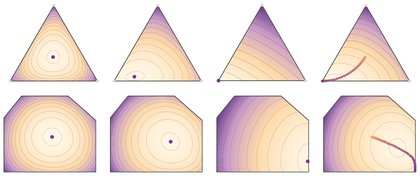

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-entropy-lp-geometry.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-entropy-lp-geometry.png")
display(Image(filename=str(_thumb)))
